<a href="https://colab.research.google.com/github/JulTob/Data/blob/main/Markov/Problema_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problema Estadística

Un contratista independiente para reformar techos ha determinado que el número de trabajos que se solicitan para el mes de septiembre es bastante variable. A partir de la experiencia anterior, las probabilidades de obtener 0, 1, 2 o 3 trabajos se han determinado como 0.1, 0.35, 0.30 y 0.25, respectivamente.



In [94]:
P = [0.1, 0.35, 0.30, 0.25]
X = [0, 1, 2, 3]

Asumiendo que todos los meses se comportan igual, queremos saber:

1. ¿Cuál es la probabilidad de que esté parado un mes?

In [95]:
print(f"Probabilidad de 0 trabajos: {P[0] = }")

Probabilidad de 0 trabajos: P[0] = 0.1


2. ¿Cuál es la probabilidad de que tenga al menos 2 trabajos en un mes?

In [96]:
p_2plus = 0
for i in X:
    if i >= 2:
        print(f"Probabilidad de {i} trabajos: {P[i] = }")
        p_2plus += P[i]
print(f"Probabilidad de al menos 2 trabajos: {p_2plus = }")


Probabilidad de 2 trabajos: P[i] = 0.3
Probabilidad de 3 trabajos: P[i] = 0.25
Probabilidad de al menos 2 trabajos: p_2plus = 0.55


3. ¿Cuántos trabajos espera tener en un mes?


In [97]:
mean = sum([i * P[i] for i in X])
print(f"Media: {mean = }")

Media: mean = 1.7


4. Da una medida de incertidumbre sobre el número de trabajos que espera tener en un mes


In [98]:
var = sum([(i - mean)**2 * P[i] for i in X])
print(f"Varianza: {var = }")
print(f"Desviación típica: {var**0.5 = }")

Varianza: var = 0.91
Desviación típica: var**0.5 = 0.9539392014169457


5. Simula los trabajos que podría conseguir durante un año entero (si todos los meses son iguales). Calcula la media y la desviación típica, y compárala con los valores teóricos.


In [99]:
import math
print("Valores esperados teóricos:")
print(f"Esperanza en 12 meses: {12 * mean = }")
# La varianza de la suma de variables independientes es la suma de las varianzas
var12 = 12 * var
print(f"Varianza en 12 meses: { var12 = }")
dst12 = math.sqrt(var12)
print(f"Desviación típica en 12 meses: {dst12 = }")

Valores esperados teóricos:
Esperanza en 12 meses: 12 * mean = 20.4
Varianza en 12 meses:  var12 = 10.92
Desviación típica en 12 meses: dst12 = 3.304542328371661


In [105]:
print("Simulación:")


#seed(42)

yearly = choices(X, P, k=12)
print(f"Clientes al año: {sum(yearly)}")


def Simulation(X, P, T=100, n=100):
    """
    X: List of values
    P: List of probabilities
    T: Number of trials
    n: Number of simulations
    """
    Y = list()
    for i in range(n):
        Y.append(
            sum(
                choices(X, P, k=T)))
        #--

    mean_y = sum(Y)/len(Y)
    var_y  = sum([(y - mean_y)**2 for
                  y in Y])/len(Y)
    sd_y = var_y**0.5
    return (mean_y, var_y, sd_y)

(mean_y, var_y, sd_y) = Simulation(X, P, 12)

print(f"Media: {mean_y}")
print(f"Varianza: {var_y}")
print(f"DSt: {sd_y}")

Simulación:
Clientes al año: 25
Media: 20.71
Varianza: 10.7059
DSt: 3.2719871637890026


6. Simula los trabajos que podría conseguir durante 30 años (si todos los meses y todos los años son iguales). Calcula la media y la desviación típica, y compárala con los valores teóricos.

In [106]:
import math
print("Valores esperados teóricos de 30 años:")
print(f"Esperanza en 30 años: {30 * 12 * mean = }")
# La varianza de la suma de variables independientes es la suma de las varianzas
var30a = 30 * 12 * var
print(f"Varianza: { var30a = }")
dst30 = math.sqrt(var30a)
print(f"Desviación típica en 30 años: {dst30 = }")

Valores esperados teóricos de 30 años:
Esperanza en 30 años: 30 * 12 * mean = 612.0
Varianza:  var30a = 327.6
Desviación típica en 30 años: dst30 = 18.099723754798028


In [110]:
(mean_y, var_y, sd_y) = Simulation(X, P, 12*30)

print(f"Media: {mean_y}")
print(f"Varianza: {var_y}")
print(f"DSt: {sd_y}")

Media: 614.29
Varianza: 345.9859
DSt: 18.60069622352884




7. Representa el comportamiento de la media y la desviación típica calculadas con simulaciones, conforme aumenta el tamaño de la muestra.



In [111]:
Y = list()
for i in range(12*30):
    Y.append(Simulation(X,P,i))



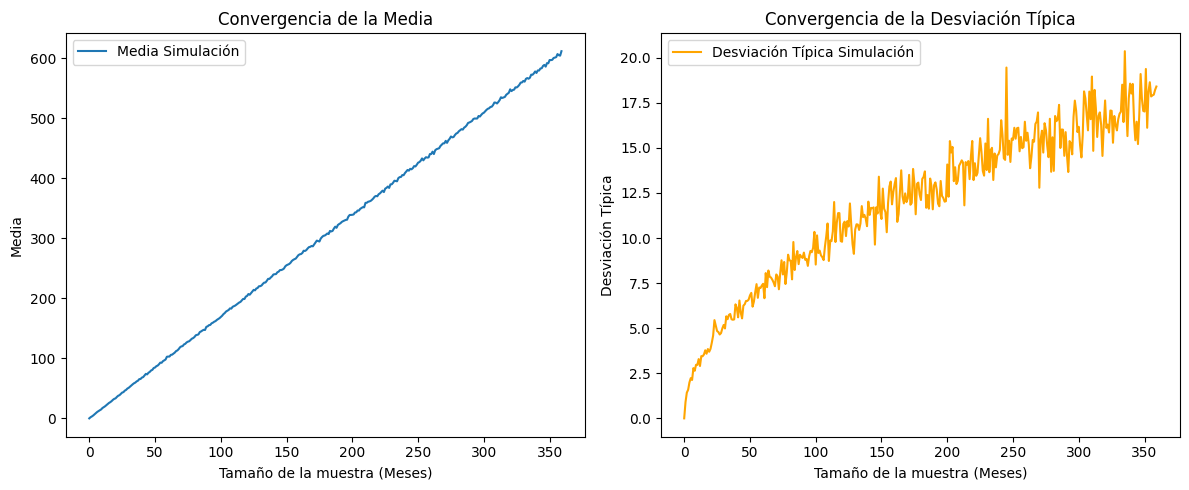

In [113]:
import matplotlib.pyplot as plt

# Extract means and standard deviations from Y
means = [y[0] for y in Y]
sds = [y[2] for y in Y]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Mean
ax1.plot(means, label='Media Simulación')
ax1.set_title('Convergencia de la Media')
ax1.set_xlabel('Tamaño de la muestra (Meses)')
ax1.set_ylabel('Media')
ax1.legend()

# Plot Standard Deviation
ax2.plot(sds, label='Desviación Típica Simulación', color='orange')
ax2.set_title('Convergencia de la Desviación Típica')
ax2.set_xlabel('Tamaño de la muestra (Meses)')
ax2.set_ylabel('Desviación Típica')
ax2.legend()

plt.tight_layout()
plt.show()